In [1]:
# General notebook settings
import logging
import warnings

import pypsa

warnings.filterwarnings("error", category=DeprecationWarning)
# pandas<3.0.3 sets the `locs` attribute deprecated in matplotlib>=3.11
warnings.filterwarnings("ignore", message="The locs attribute was deprecated")
logging.getLogger("gurobipy").propagate = False
pypsa.options.params.optimize.log_to_console = False

# Global Sensitivity Analysis

This example demonstrates how PyPSA can be combined with Global Sensitivity Analysis (GSA) methods using Sobol indices to understand how capital cost uncertainties affect system design and costs. The third-party tool [SALib](https://salib.readthedocs.io) is used for this example. It makes sense to first read the basic SALib [tutorial](https://salib.readthedocs.io/en/latest/user_guide/basics.html) to understand the concepts before diving into this example.

## Import Required Libraries

We'll need PyPSA for energy system modelling and SALib for global sensitivity analysis functions. We'll also use a thread pool to evaluate scenarios in parallel — threads work reliably in notebooks on every operating system, and the solver still runs in parallel because it releases the GIL during optimisation.

In [2]:
import logging
import warnings
from functools import partial
from multiprocessing import cpu_count
from multiprocessing.pool import ThreadPool

import matplotlib.pyplot as plt
import numpy as np
from SALib.analyze.sobol import analyze as sobol_analyze
from SALib.sample.sobol import sample as sobol_sample

import pypsa

THREADS = min(cpu_count(), 15)

# Set to True for interaction effects
SECOND = False

# Small number of samples for demo; use 64+ for real analysis
SAMPLES = 8

logging.basicConfig(level=logging.ERROR)
logging.getLogger("linopy").setLevel(logging.ERROR)

warnings.simplefilter(action="ignore", category=FutureWarning)

## Create Base PyPSA Model

We will re-use the [model.energy](https://model.energy) style example network. The model is a single-node capacity expansion model with only wind, solar, battery and hydrogen storage to cover a year of hourly demand. To save some computation time, we will sample just every fifth day of the year. Each day is considered at 3-hourly resolution, so we will have 8 snapshots per representative day.

In [3]:
n = pypsa.examples.model_energy()
selected = n.snapshots.normalize().unique()[::5]
snapshots = n.snapshots[n.snapshots.normalize().isin(selected)]
n.set_snapshots(snapshots)
n.snapshot_weightings[["objective", "generators"]] *= 5

## Define Uncertainty Parameters

We specify which technology costs are uncertain, how much they can vary and what distribution to use for sampling. The uncertainties are defined as scaling factors relative to the base investment costs for solar, wind, batteries and electrolysers.

In [4]:
uncertainty_space = {
    "num_vars": 4,
    "names": ["solar", "wind", "battery", "electrolysis"],
    "bounds": [
        [0.6, 1],
        [0.8, 1],
        [0.6, 1],
        [0.6, 1],
    ],
    "dists": ["unif"] * 4,
}

## Generate Sample Points

Sobol sampling creates a systematic set of parameter combinations that efficiently explores the uncertainty space (low-discrepancy series). Each row represents one scenario to simulate.

In [5]:
samples = sobol_sample(uncertainty_space, SAMPLES, calc_second_order=SECOND)
display(samples[:4])
display(len(samples))

array([[0.99714928, 0.93122843, 0.71822925, 0.78707731],
       [0.74924616, 0.93122843, 0.71822925, 0.78707731],
       [0.99714928, 0.83359811, 0.71822925, 0.78707731],
       [0.99714928, 0.93122843, 0.92453035, 0.78707731]])

48

## Define Evaluation Function

This function takes the sampled cost scaling factors, applies them to the network, runs optimization, and extracts the total system cost and optimal capacities.

In [6]:
def evaluate(
    s: np.ndarray, n: pypsa.Network
) -> tuple[float, float, float, float, float]:
    """Optimize with given scaling factors and evaluate system costs and capacities."""
    n_sim = n.copy()

    attr = "capital_cost"
    n_sim.generators.loc["solar", attr] = s[0] * n.generators.loc["solar", attr]
    n_sim.generators.loc["wind", attr] = s[1] * n.generators.loc["wind", attr]
    n_sim.storage_units.loc["battery storage", attr] = (
        s[2] * n.storage_units.loc["battery storage", attr]
    )
    n_sim.links.loc["electrolysis", attr] = s[3] * n.links.loc["electrolysis", attr]

    n_sim.optimize(solver_name="gurobi")

    tsc = (n_sim.statistics.opex().sum() + n_sim.statistics.capex().sum()) / 1e9
    solar = n_sim.generators.p_nom_opt["solar"] / 1e3
    wind = n_sim.generators.p_nom_opt["wind"] / 1e3
    battery = n_sim.storage_units.p_nom_opt["battery storage"] / 1e3
    electrolysis = n_sim.links.p_nom_opt["electrolysis"] / 1e3

    return tsc, solar, wind, battery, electrolysis

## Run Sensitivity Analysis

We use parallel processing to evaluate all sample scenarios simultaneously, significantly reducing computation time. Each simulation optimizes the energy system with different cost assumptions and returns the total system cost and optimal capacities.

In [7]:
with ThreadPool(processes=THREADS) as pool:
    func = partial(evaluate, n=n)
    results = np.array(pool.map(func, samples))
display(results[:4])

Set parameter WLSAccessID


Set parameter WLSSecret


Set parameter LicenseID to value 2537914


Academic license 2537914 - for non-commercial use only - registered to l.___@tu-berlin.de


Read LP format model from file /tmp/linopy-problem-a6v0h9kr.lp


...

Set parameter LogToConsole to value 0
Read LP format model from file /tmp/linopy-problem-flpg4wnk.lp


Reading time = 0.01 seconds


obj: 12854 rows, 5846 columns, 24832 nonzeros


Set parameter LogToConsole to value 0


array([[ 6.28639383, 32.44546633, 25.80160061, 24.47716844,  1.87746915],
       [ 5.86079811, 35.10988217, 25.70471012, 21.66994592,  1.87360592],
       [ 6.02814683, 31.87846354, 26.15496631, 25.56234607,  1.72600994],
       [ 6.58281884, 34.77195601, 25.08658674, 21.09813717,  2.24013892]])

## Visualize Sensitivity Indices

Sobol analysis calculates sensitivity indices showing how much each technology's cost uncertainty contributes to variability in system outcomes (i.e. total system cost and expanded capacities). The larger the index, the more impact that technology's cost has on the outcome. First-order indices show direct effects. Error bars indicate 95% confidence intervals. Note that for `SAMPLES = 16`, the confidence intervals may be quite large, so larger sample sizes are recommended for more reliable results.

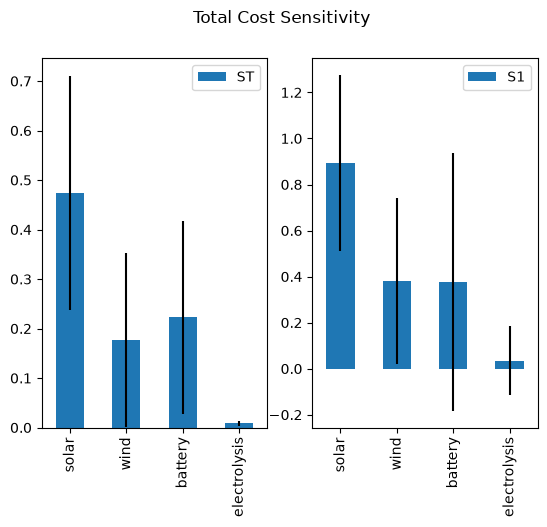

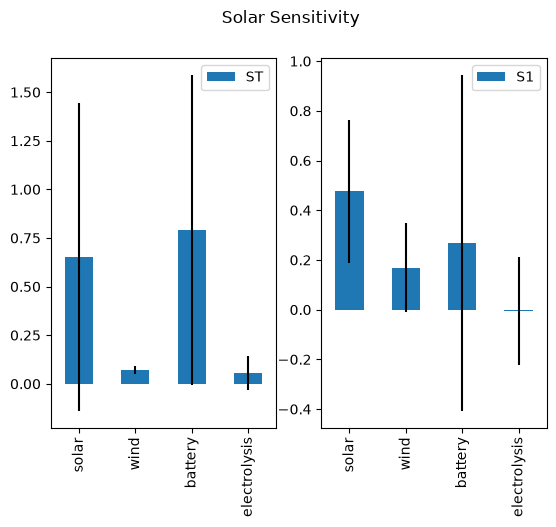

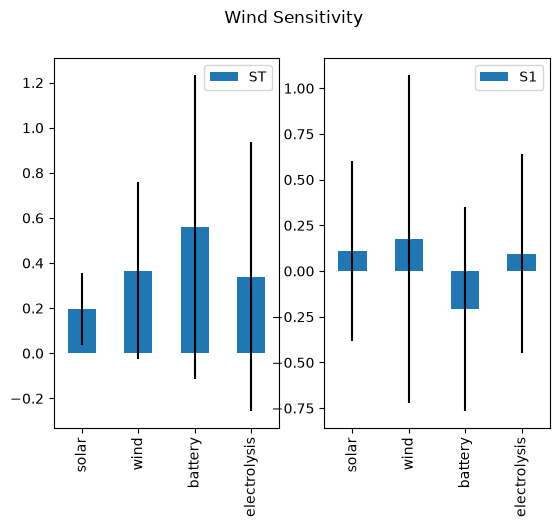

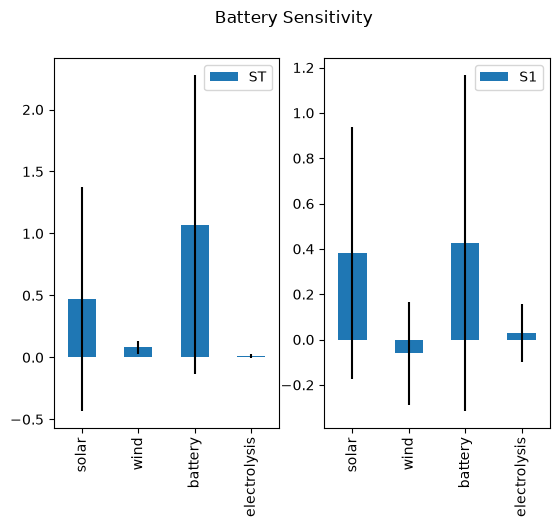

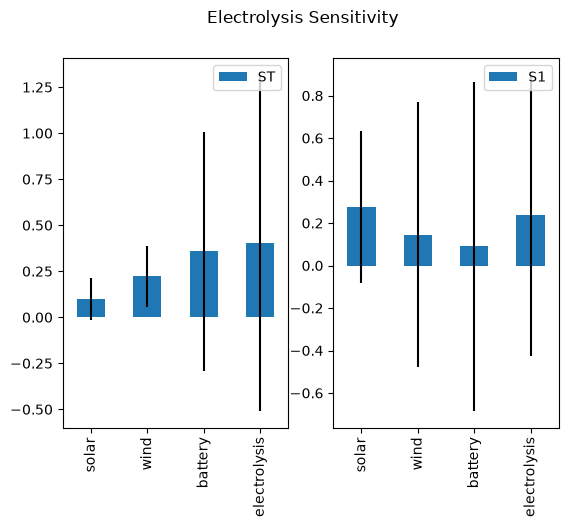

In [8]:
outputs = ["Total Cost", "Solar", "Wind", "Battery", "Electrolysis"]
for i, output in enumerate(outputs):
    sobol_analyze(uncertainty_space, results[:, i], calc_second_order=SECOND).plot()
    plt.gcf().suptitle(f"{output} Sensitivity")

These illustrative results show that solar and battery costs have the largest impact on total system cost.
The deployment of solar also substantially depends on the cost of batteries (next to its own cost).

For more global sensitivity analysis functions, like the [Method of Morris](https://en.wikipedia.org/wiki/Morris_method), see the [SALib documentation](https://salib.readthedocs.io/en/latest/).

## References

- Herman and Usher (2017). [SALib: An open-source Python library for Sensitivity Analysis](https://doi.org/10.21105/joss.00097), Journal of Open Source Software (JOSS).

- Usher et al. (2023), [Global sensitivity analysis to enhance the transparency and rigour of energy system optimisation modelling](https://doi.org/10.12688/openreseurope.15461.1), Open Research Europe.

- Tröndle et al. (2020), [Trade-Offs between Geographic Scale, Cost, and Infrastructure Requirements for Fully Renewable Electricity in Europe](https://doi.org/10.1016/j.joule.2020.07.018), Joule.

- Neumann et al. (2023), [Broad ranges of investment configurations for renewable power systems, robust to cost uncertainty and near-optimality](https://doi.org/10.1016/j.isci.2023.106702), iScience.

